# FoodBridge AI — Feature Engineering

**Dataset:** `synthetic_donations.csv`
**Goal:** Apply the `FeatureEngineer` class to the raw data and inspect the resulting feature matrix.
**Author:** FoodBridge AI ML Team

---


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root to sys.path so we can import ml.features.engineering
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from ml.features.engineering import FeatureEngineer

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})


## 1. Load Raw Data

In [2]:
DATA_PATH = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..', 'data')), "synthetic_donations.csv")

# Fallback for different working directories
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", "data", "synthetic_donations.csv")

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded raw data: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Loaded raw data: 10,000 rows x 9 columns


,food_type,quantity,prep_time_hour,expiry_minutes,distance_km,weather_temp,ngo_capacity,traffic_factor,delivered_on_time
0,Mixed,6,7,138,0.92,28.2,100,1.014,1
1,Roti,51,9,87,0.52,28.2,75,1.038,1
2,Bread,52,8,222,0.91,28.3,40,1.212,0
3,Dal,27,7,155,16.81,38.6,40,2.272,1
4,Rice,42,19,97,1.79,31.7,40,1.082,1


## 2. Apply Feature Engineering pipeline

In [3]:
fe = FeatureEngineer()
df_transformed, feature_names = fe.transform(df_raw)

print("=" * 50)
print("  SHAPE COMPARISON")
print("=" * 50)
print(f"  Shape before : {df_raw.shape}")
print(f"  Shape after  : {df_transformed.shape}")

print("\n=" * 50)
print("  FEATURE NAMES")
print("=" * 50)
print(f"Total features: {len(feature_names)}")
for f in feature_names:
    print(f"  - {f}")


  SHAPE COMPARISON
  Shape before : (10000, 9)
  Shape after  : (10000, 21)

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  FEATURE NAMES
Total features: 20
  - quantity
  - expiry_minutes
  - weather_temp
  - ngo_capacity
  - traffic_factor
  - time_to_expiry
  - food_perishability_score
  - capacity_ratio
  - is_peak_hour
  - dist_very_near
  - dist_near
  - dist_moderate
  - dist_far
  - food_Biryani
  - food_Bread
  - food_Curry
  - food_Dal
  - food_Mixed
  - food_Rice
  - food_Roti


## 3. Inspect Transformed Matrix

In [4]:
# Show first 5 rows of transformed features
df_transformed.head()


,quantity,expiry_minutes,weather_temp,ngo_capacity,traffic_factor,delivered_on_time,time_to_expiry,food_perishability_score,capacity_ratio,is_peak_hour,...,dist_near,dist_moderate,dist_far,food_Biryani,food_Bread,food_Curry,food_Dal,food_Mixed,food_Rice,food_Roti
0,6,138,28.2,100,1.014,1,136.13424,0.75,0.060,1,...,0,0,0,0,0,0,0,1,0,0
1,51,87,28.2,75,1.038,1,85.92048,0.90,0.680,1,...,0,0,0,0,0,0,0,0,0,1
2,52,222,28.3,40,1.212,0,219.79416,0.30,1.000,1,...,0,0,0,0,1,0,0,0,0,0
3,27,155,38.6,40,2.272,1,78.61536,0.50,0.675,1,...,0,0,1,0,0,0,1,0,0,0
4,42,97,31.7,40,1.082,1,93.12644,0.80,1.000,1,...,0,0,0,0,0,0,0,0,1,0


## 4. Feature Importance Proxy (Correlation with Label)

We check how each newly engineered feature correlates with our target label `delivered_on_time`.


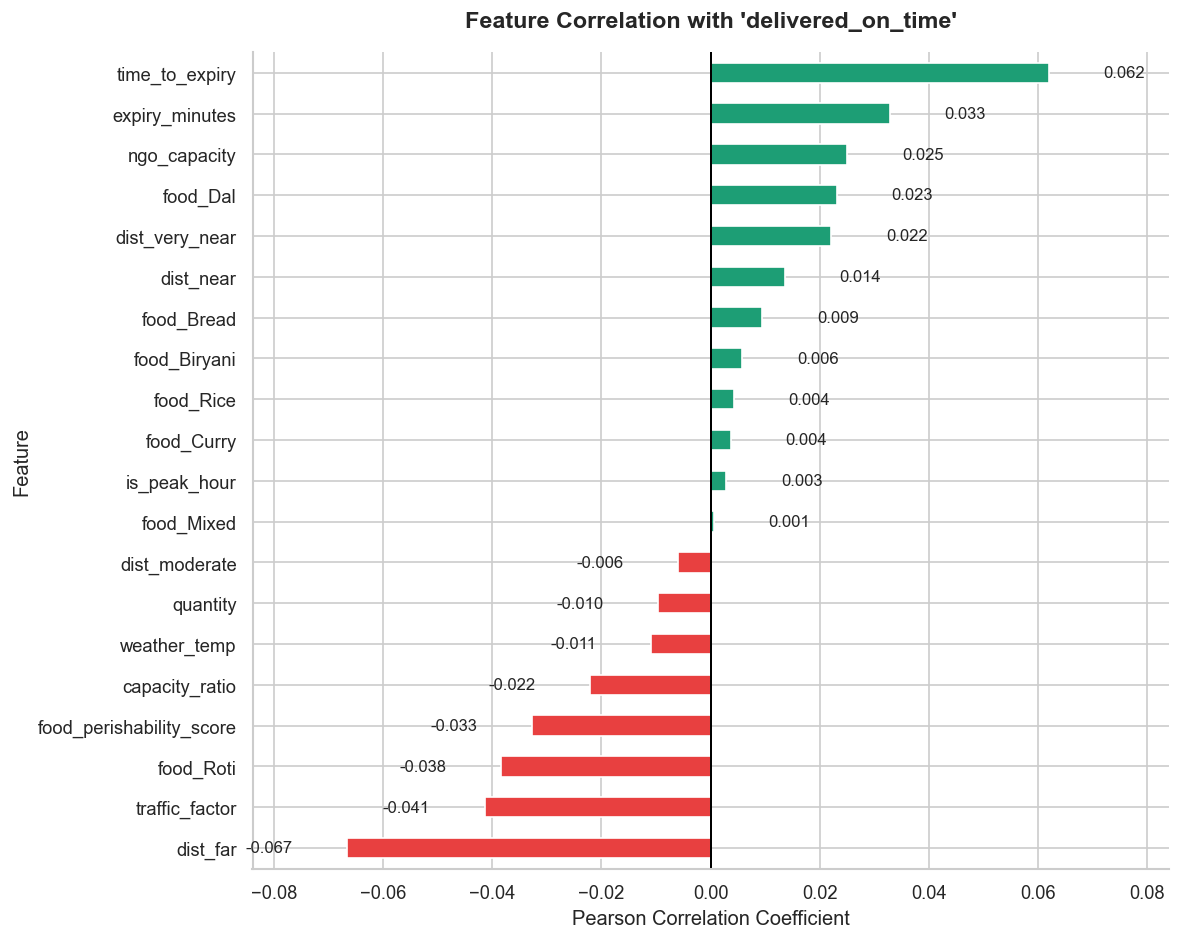

In [5]:
# Calculate correlation of all features with the label
correlations = df_transformed.corr()["delivered_on_time"].drop("delivered_on_time").sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#E84040" if c < 0 else "#1D9E75" for c in correlations]
correlations.plot(kind="barh", color=colors, ax=ax)

ax.set_title("Feature Correlation with 'delivered_on_time'", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_ylabel("Feature")
ax.axvline(0, color="black", linewidth=1.2)

# Annotate values
for idx, val in enumerate(correlations):
    offset = 0.01 if val > 0 else -0.01
    ha = "left" if val > 0 else "right"
    ax.text(val + offset, idx, f"{val:.3f}", va="center", ha=ha, fontsize=10)

# Expand x-limits slightly to make room for annotations
xmin, xmax = ax.get_xlim()
limit = max(abs(xmin), abs(xmax)) * 1.15
ax.set_xlim(-limit, limit)

plt.tight_layout()
plt.show()
